### ising test

In [11]:
import importlib, monte_carlo, accumulator
importlib.reload(accumulator); importlib.reload(monte_carlo)
from monte_carlo import MonteCarlo
from ising_lattice import IsingLattice
import numpy as np
import time

# ─── Parameters ───────────────────────────────────────────────────────────────
SIZES  = [8, 12, 16]
J      = -1.0
T_C    = 2 / np.log(1 + np.sqrt(2))
T_LIST = np.linspace(1.5, 3.5, 41)

WARMUP_METRO = 1;  STEPS_METRO = 1_000_000
WARMUP_WOLFF = 1;  STEPS_WOLFF = 2000

METHODS = ['metropolis', 'wolff']  #['wolff']#

# ─── Sweep ────────────────────────────────────────────────────────────────────
# results[method][label] = {T, chi, chi_err, binder, binder_err, C, C_err}
results = {m: {} for m in METHODS}
timing  = {m: {} for m in METHODS}   # timing[method][label] = total seconds

t_total_start = time.perf_counter()

for L in SIZES:
    label = f'L={L}'
    print(f'\n══════  {label}  ══════')
    for method in METHODS:
        warmup = WARMUP_METRO if method == 'metropolis' else WARMUP_WOLFF
        steps  = STEPS_METRO  if method == 'metropolis' else STEPS_WOLFF
        print(f'  ── {method} ──')

        chi_v, chi_e   = [], []
        bind_v, bind_e = [], []
        C_v, C_e       = [], []

        t_method_start = time.perf_counter()

        for T in T_LIST:
            t0  = time.perf_counter()
            lat = IsingLattice(L, L, J=J)
            mc  = MonteCarlo(lat)
            mc.run_loop(warmup_steps=warmup, steps=steps, T=T,
                        method=method, save_warmup=False)
            acc = mc.acc
            dt  = time.perf_counter() - t0

            # susceptibility — post-hoc from |M| moments
            chi_mean = acc.compute_susceptibility(T)
            chi_err  = acc.mean_and_error(acc.m_abs_array)[1] * lat.N / T
            chi_v.append(chi_mean);  chi_e.append(chi_err)

            # Binder cumulant — block jackknife error
            binder, binder_err = acc.compute_binder_and_error(acc.m2_array, acc.m4_array)
            bind_v.append(binder);  bind_e.append(binder_err)

            # specific heat
            C     = acc.compute_specific_heat(T)
            E_arr = np.asarray(acc.energy)
            _, C_err = acc.mean_and_error(E_arr**2 - E_arr.mean()**2)
            C_err /= (lat.N * T**2)
            C_v.append(C);  C_e.append(C_err)

            print(f'    T={T:.2f}  χ={chi_mean:.2f}±{chi_err:.2f}'
                  f'  U4={binder:.3f}±{binder_err:.3f}  C={C:.3f}'
                  f'  [{dt:.1f}s]')

        t_method = time.perf_counter() - t_method_start
        timing[method][label] = t_method
        print(f'  → {label} {method} total: {t_method:.1f}s  ({t_method/len(T_LIST):.1f}s / T-point)')

        results[method][label] = dict(
            T          = T_LIST,
            chi        = np.array(chi_v),   chi_err    = np.array(chi_e),
            binder     = np.array(bind_v),  binder_err = np.array(bind_e),
            C          = np.array(C_v),     C_err      = np.array(C_e),
        )

t_total = time.perf_counter() - t_total_start
print(f'\n✓ Done.  Total wall time: {t_total/60:.1f} min')

# ─── Timing summary table ─────────────────────────────────────────────────────
print('\n── Timing summary (seconds) ──')
print(f'{"":14}' + ''.join(f'{f"L={L}":>10}' for L in SIZES))
for method in METHODS:
    print(f'{method:14}' + ''.join(f'{timing[method][f"L={L}"]:>10.1f}' for L in SIZES))



══════  L=8  ══════
  ── metropolis ──


100%|██████████| 1000000/1000000 [00:36<00:00, 27241.09it/s]


    T=1.50  χ=0.03±0.03  U4=0.666±0.000  C=0.209  [36.7s]


100%|██████████| 1000000/1000000 [00:35<00:00, 27993.98it/s]


    T=1.55  χ=0.05±0.04  U4=0.665±0.000  C=0.246  [35.8s]


...

    T=3.40  χ=0.64±0.66  U4=0.135±0.055  C=1.358  [0.3s]


100%|██████████| 2000/2000 [00:00<00:00, 6289.80it/s]


    T=3.45  χ=0.73±0.76  U4=-0.037±0.075  C=1.167  [0.3s]


100%|██████████| 2000/2000 [00:00<00:00, 6200.65it/s]

    T=3.50  χ=0.68±0.78  U4=0.032±0.086  C=0.993  [0.3s]
  → L=16 wolff total: 45.4s  (1.1s / T-point)

✓ Done.  Total wall time: 223.7 min

── Timing summary (seconds) ──
                     L=8      L=12      L=16
metropolis        2160.4    4827.5    6348.7
wolff               14.7      25.2      45.4


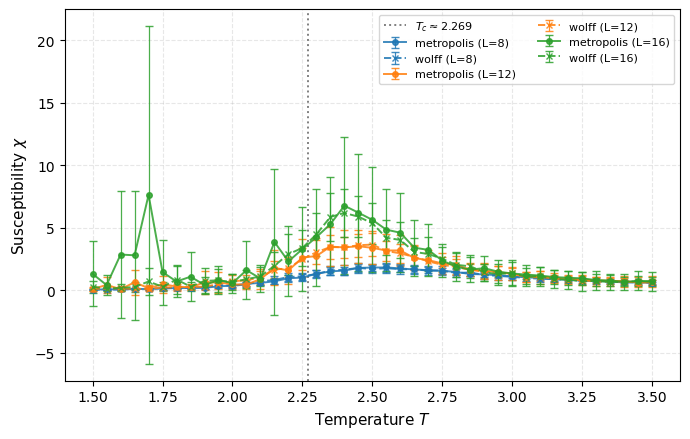

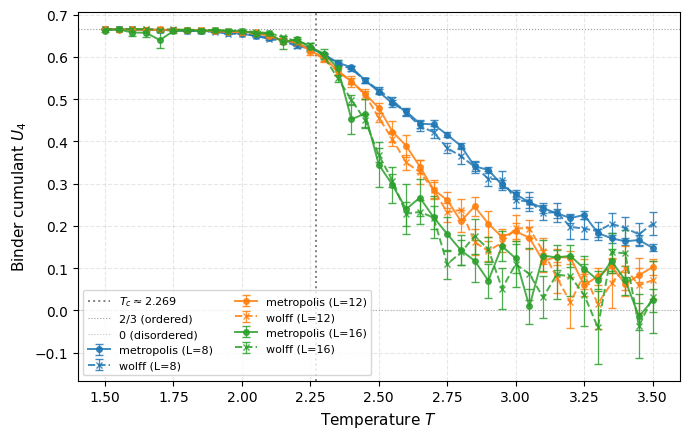

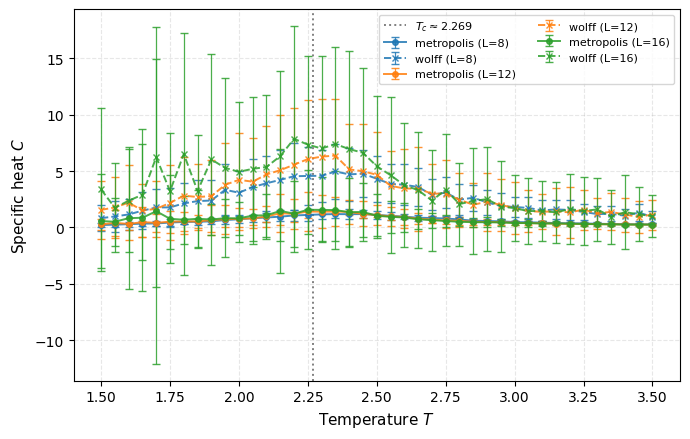

In [12]:
import matplotlib.pyplot as plt

observables = [
    ('chi',   'chi_err',   r'Susceptibility $\chi$'),
    ('binder','binder_err',r'Binder cumulant $U_4$'),
    ('C',     'C_err',     r'Specific heat $C$'),
]

size_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
method_ls   = {'metropolis': '-',  'wolff': '--'}
method_mk   = {'metropolis': 'o',  'wolff': 'x'}

for key, err_key, ylabel in observables:
    fig, ax = plt.subplots(figsize=(7, 4.5))

    for i, L in enumerate(SIZES):
        label_L = f'L={L}'
        color   = size_colors[i % len(size_colors)]

        for method in METHODS:
            d = results[method][label_L]
            ax.errorbar(
                d['T'], d[key], yerr=d[err_key],
                label      = f'{method} ({label_L})',
                color      = color,
                linestyle  = method_ls[method],
                marker     = method_mk[method],
                markersize = 4,
                capsize    = 3,
                linewidth  = 1.4,
                elinewidth = 0.9,
                alpha      = 0.85,
            )

    ax.axvline(T_C, color='gray', linestyle=':', linewidth=1.4,
               label=f'$T_c \\approx {T_C:.3f}$')

    if key == 'binder':
        ax.axhline(2/3, color='k', linestyle=':', linewidth=0.8, alpha=0.4,
                   label='2/3 (ordered)')
        ax.axhline(0,   color='k', linestyle=':', linewidth=0.8, alpha=0.25,
                   label='0 (disordered)')

    ax.set_xlabel('Temperature $T$', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.legend(fontsize=8, ncol=2)
    ax.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.savefig(f'ising_{key}_all.png', dpi=150, bbox_inches='tight')
    plt.show()

[1.5        1.60526316 1.71052632 1.81578947 1.92105263 2.02631579
 2.13157895 2.23684211 2.34210526 2.44736842 2.55263158 2.65789474
 2.76315789 2.86842105 2.97368421 3.07894737 3.18421053 3.28947368
 3.39473684 3.5       ]


In [10]:
np.linspace(1.5, 3.5, 20)

array([1.5       , 1.60526316, 1.71052632, 1.81578947, 1.92105263,
       2.02631579, 2.13157895, 2.23684211, 2.34210526, 2.44736842,
       2.55263158, 2.65789474, 2.76315789, 2.86842105, 2.97368421,
       3.07894737, 3.18421053, 3.28947368, 3.39473684, 3.5       ])